# Convolution of an Audio Signal with a Room Impulse Response

*This Jupyter notebook is part of a [collection of notebooks](../index.ipynb) in the masters course Selected Topics in Audio Signal Processing, Communications Engineering, Universität Rostock. Please direct questions and suggestions to [Sascha.Spors@uni-rostock.de](mailto:Sascha.Spors@uni-rostock.de).*

## Theory

The propagation of sound in rooms is modeled by the linear [wave equation](https://en.wikipedia.org/wiki/Wave_equation), a second-order linear partial differential equation with constant coefficients. Consequently, the propagation path from a source (e.g. loudspeaker) at one position to a receiver (e.g. microphone) at another position can be interpreted as a linear time-invariant (LTI) system. This system is characterized for instance by the impulse response between these two positions. This fact can be used for the synthesis of virtual acoustic environments. If a source signal (e.g. speech, instrument) without any room effect is convolved with the impulse response of a room (e.g. concert hall), the impression is created that the source plays in the room. This is also known as [convolution reverb](https://en.wikipedia.org/wiki/Convolution_reverb).

## Read Speech Signal

First a source signal $x[k]$ is loaded into the vector `x` using the [`soundfile`](http://pysoundfile.readthedocs.io/en/latest/) module for Python

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
import requests, io
from scipy.io import wavfile
from IPython.display import Audio, display

def carregar_wav(url, fallback_fs=16000, fallback_dur=3.0, timeout=20):
    # Baixa um .wav por URL (notebook autocontido). Se a rede/URL falhar,
    # gera um sinal sintetico para rodar do zero em qualquer ambiente (ex.: CI).
    try:
        R = requests.get(url, timeout=timeout, headers={"User-Agent": "Mozilla/5.0"})
        R.raise_for_status()
        fs, data = wavfile.read(io.BytesIO(R.content))
        data = np.asarray(data, dtype=float)
        if data.ndim > 1:
            data = data[:, 0]
        return data / (np.max(np.abs(data)) or 1.0), int(fs)
    except Exception as e:
        print(f"[aviso] download falhou ({type(e).__name__}); usando sinal sintetico.")
        fs = fallback_fs
        t = np.linspace(0, fallback_dur, int(fs * fallback_dur), endpoint=False)
        voz = sum((1.0 / k) * np.sin(2 * np.pi * 150 * k * t) for k in range(1, 8))
        voz *= 0.4 + 0.6 * np.abs(np.sin(2 * np.pi * 2.5 * t))
        return voz / np.max(np.abs(voz)), fs

URL_FALA = "https://raw.githubusercontent.com/LCAV/pyroomacoustics/master/examples/input_samples/cmu_arctic_us_aew_a0001.wav"
x, fs = carregar_wav(URL_FALA)

The input signal $x[k]$ is plotted. For ease of illustration, the sample index $k$ is interpreted as time $t = k T$ with the sampling interaval $T$.

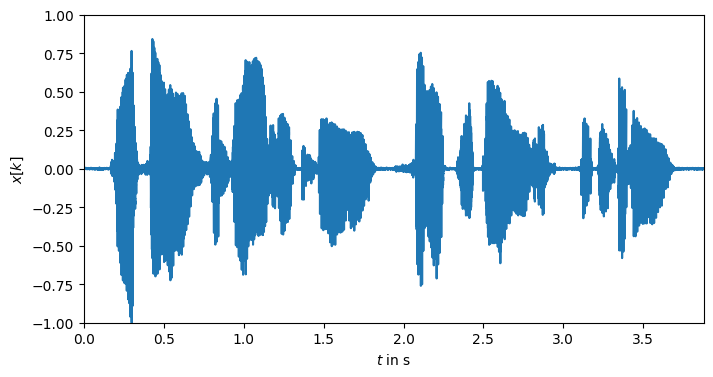

In [2]:
plt.figure(figsize=(8,4))
t = np.arange(len(x)) / fs
plt.plot(t, x)
plt.xlabel(r'$t$ in s')
plt.ylabel(r'$x[k]$')
plt.axis([0, t[-1], -1, 1]);

## Read Room Impulse Response

The impulse response $h[k]$ of the room is loaded into the vector `h`

In [3]:
# Resposta ao impulso de sala (RIR) sintetica: som direto + reflexoes iniciais
# + cauda reverberante com decaimento exponencial. Substitui um .wav de RIR,
# mantendo o notebook autocontido.
fsh = fs
dur_rir = 0.4
n = int(dur_rir * fsh)
t_rir = np.arange(n) / fsh
rng = np.random.default_rng(0)
h = rng.standard_normal(n) * np.exp(-7.0 * t_rir)
h[0] = 1.0
for atraso, ganho in [(0.011, 0.6), (0.019, 0.4), (0.031, 0.3), (0.043, 0.2)]:
    i = int(atraso * fsh)
    if i < n:
        h[i] += ganho
h = h / np.max(np.abs(h))

The room impulse response is plotted for illustration

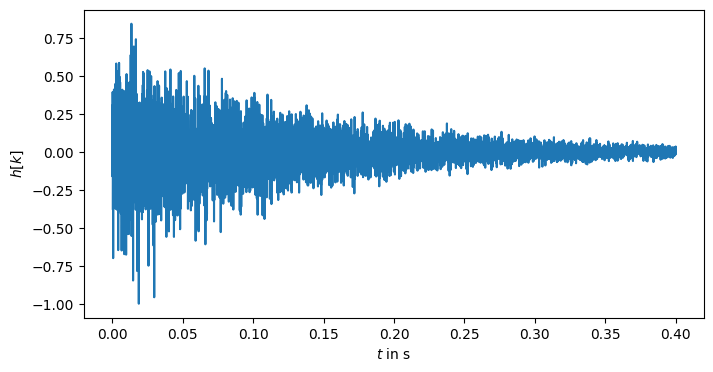

In [4]:
plt.figure(figsize=(8,4))
t = 1/fs*np.arange(len(h))
plt.plot(t, h)
plt.xlabel(r'$t$ in s')
plt.ylabel(r'$h[k]$');

## Convolution

The source signal $x[k]$ is convolved with the room impulse response $h[k]$ in order to compute the output signal $y[k] = x[k] * h[k]$. The computation may take a while due to the involved numerical complexity.

In [5]:
y = np.convolve(h, x)

The output signal $y[k]$ is plotted for illustration. The effect of the room on the source signal is clearly visible.

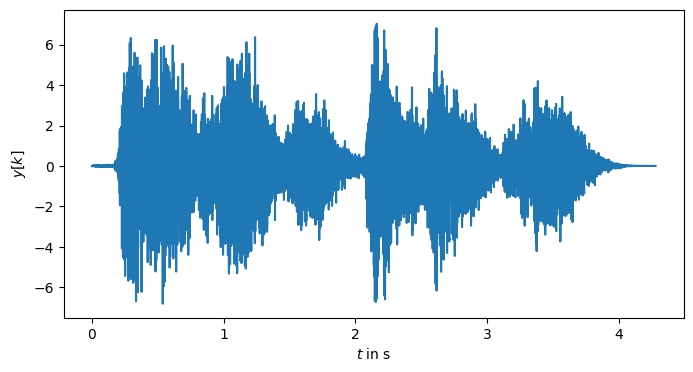

In [6]:
plt.figure(figsize=(8,4))
t = 1/fs*np.arange(len(y))
plt.plot(t, y)
plt.xlabel(r'$t$ in s')
plt.ylabel(r'$y[k]$');

## Auralization

The input signal $x[k]$ and the output signal $y[k]$ are normalized and written to files for the purpose of auralization.

In [7]:
# Auralizacao: normaliza e ouve o sinal seco (entrada) e o molhado (com sala).
seco = x / np.max(np.abs(x))
molhado = y / np.max(np.abs(y))
print("Sinal seco (sem sala):")
display(Audio(seco, rate=fs))
print("Sinal com a sala (convoluido com a RIR):")
display(Audio(molhado, rate=fs))

Sinal seco (sem sala):


Sinal com a sala (convoluido com a RIR):


Listen to the 'dry' source signal without room effect (input) and the 'wet' signal including the room effect (output) using the embedded controls below.

**Sinal seco (sem sala)** — reproduzido na célula acima (entrada $x[k]$).

**Sinal com a sala (reverberação)** — reproduzido na célula acima (saída $y[k]$).

**Copyright**

This notebook is provided as [Open Educational Resources](https://en.wikipedia.org/wiki/Open_educational_resources). Feel free to use the notebook for your own purposes. The text/images/data are licensed under [Creative Commons Attribution 4.0](https://creativecommons.org/licenses/by/4.0/), the code of the IPython examples under the [MIT license](https://opensource.org/licenses/MIT). Please attribute the work as follows: *Sascha Spors, Selected Topics in Audio Signal Processing - Supplementary Material, 2017*.